In [ ]:
#                                                                [   SECTION - A   ]


In [ ]:
#                                                                     Scenario - 1

Delivery Fee Calculator (NumPy Vectorisation)

# Vectorisation Superiority :
            NumPy vectorisation is better than a Python for loop because it can perform calculations on the whole array at once. 
It is usually faster and uses less code, especially for a large dataset like 50,000 orders.

# Broadcasting: 
           When a scalar fee rate (e.g., Rs 5/km) is applied to an array of shape (50000,),
NumPy automatically stretches the scalar across array dimensions without memory duplication, performing elementwise multiplication seamlessly.

    eg ->   Distances: [2, 5, 3, 10] 
            Fee: [10, 25, 15, 50]  # each distance can be count like  { 5 * 5 = 25 }

In [ ]:
#                                                                   Scenario  -  2

#  Why groupby() + agg() is better than a for-loop:
       
       Performance  =>  A Python for-loop manually iterates over rows, making it very slow for large datasets. 
Pandas groupby() uses C-optimized Split-Apply-Combine operations, which execute much faster and use less memory.   

       Code Simplicity  => It replaces multiple lines of loop logic with a single, readable line of code.  
    
[  The method chain would be:   ] 

    restaurant_summary = df.groupby('restaurant_name').agg({
    'order_value': 'mean',
    'delivery_time_mins': 'mean',
    'rating': 'mean'
})
       
#  The resulting DataFrame has restaurant names as its index. Each row represents one restaurant, and the columns contain the calculated averages.

#  Conclusion: groupby() + agg() is a simple and efficient way to calculate multiple statistics for each restaurant without writing a separate for loop.

In [ ]:
#                                                                 Scenario  -  3
#    Chart Types & Justification:

(a) Total Orders Per Month  => 
Line Chart — Best for continuous time-series data to show trend changes over 12 months
(b) Proportion of Orders by Cuisine =>
Pie Chart (or Donut Chart) — Ideal for categorical data showing percentage breakdown of a single whole (100% total).
(c) Distribution of Delivery Times  =>
Histogram — Best for showing frequency density and spread across continuous numerical intervals.

        #  Configured as fig, axes = plt.subplots(1, 3, figsize=(15, 5)).   
        # This creates 1 row and 3 columns to place all three charts side by side in a single figure.  
 #                                                          => Conclusion: <=
Line chart, pie chart, and histogram are suitable for the three metrics, and plt.subplots(1, 3) can place them side by side in one figure.

In [ ]:
#                                                                  Scenario 4 
#      Marking the Peak in a Line Chart
#      How to Programmatically Identify and Mark the Peak =>

 Use NumPy's np.argmax() on the daily orders array to automatically locate the exact index/day of the maximum order volume.   

Call plt.annotate() using the peak point coordinates (max_day, max_volume) to display a descriptive text label with
an arrow pointing directly to that highest data point on the chart.   

#      Two Specific Parameters of plt.annotate() and What They Control:

                xy → specifies the exact position of the peak where the arrow points.
                xytext → specifies where the text label will appear.
                arrowprops → controls the arrow style connecting the label to the peak.
#                                                        =>  Conclusion: <=
np.argmax() finds the highest value, and plt.annotate() clearly marks that peak on the chart automatically.

In [ ]:
#                                                                 => Scenario 5  <= 
#        Customer Rating Distribution
Both sns.boxplot() and sns.violinplot() can show the distribution of ratings for each restaurant category.
#  But in that condition sns.barplot() is best=>
          The dataset has 10,000 rows, so a boxplot gives a clear and simple summary without making the chart too crowded.
          There are only 3 categories, so it is easy to compare the median, spread, and outliers between Fast Food, Fine Dining, and Casual.
          Ratings are on a discrete 1–5 scale, so a boxplot is useful for showing the range and possible extreme values.

# When the Other Chart Type (sns.violinplot()) is Preferable=>

sns.violinplot() is preferable when working with a continuous numerical variable to detect bimodal or multimodal distributions 
(multiple peaks/clusters in the data), which sns.boxplot() summarizes into a single box and hides.

In [ ]:
#                                                                 =>  Scenario 6  <=
#    Generating and Interpreting the Correlation Heatmap:
 A Seaborn correlation heatmap can be used to check the relationship between the eight numeric features before building a regression model.

First, calculate the correlation matrix and display it:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

 # The colour scale shows the strength and direction of the correlation:

        +1 → strong positive relationship
        0 → little or no linear relationship
        -1 → strong negative relationship

#                                                               =>  Conclusion  <=
The heatmap helps identify highly correlated features so they can be checked before training the regression model.

In [ ]:
#                                                                [   SECTION - B   ]

In [ ]:
#   Task 1: Delivery Fee Array Calculator (NumPy)

In [2]:
import numpy as np

In [3]:
np.random.seed(42)   # Step 1: Fixed seed
distances = np.random.uniform(1.0, 15.0, 25)   # Step 2: Generate 25 random distances
fees = 20 + 5 * distances   # Step 3: Calculate delivery fees
mask = fees > 60    # Step 4: Find fees greater than Rs 60
 # if {fees = [35, 45, 65, 72, 50] } 
 # result = [False, False, True, True, False]


In [4]:
print("Orders with fee above Rs 60:")
print("Distance (km)    Fee (Rs)")
for d, f in zip(distances[mask], fees[mask]):
    print(f"{d:.2f}             {f:.2f}")
print("\n")
print("Fee Statistics")
print("Minimum : ",np.min(fees))  # data ki choti value
print("Maximum :",np.max(fees)) #  data ki badi value
print("Mean :",np.mean(fees))  # data ki avrage value
print("Standard Deviation:", np.std(fees)) #data ka spread/variation.

Orders with fee above Rs 60:
Distance (km)    Fee (Rs)
14.31             91.55
11.25             76.24
9.38             66.91
13.13             85.63
9.42             67.08
10.91             74.57
14.58             92.89
12.65             83.27
8.35             61.73
9.57             67.83


Fee Statistics
Minimum :  26.440914600706172
Maximum : 92.8936896513396
Mean : 55.85591319825301
Standard Deviation: 19.56188200330544


In [5]:
#    Task 2: Restaurant Performance Analyser (Pandas)

In [6]:
import pandas as pd
import numpy as np

In [7]:
data = {
    "restaurant_name": [
        "Spice Hub", "Urban Bites", "Food Point", "Royal Dine", "Tasty Corner",
        "Spice Hub", "Urban Bites", "Food Point", "Royal Dine", "Tasty Corner",
        "Spice Hub", "Urban Bites", "Food Point", "Royal Dine", "Tasty Corner",
        "Spice Hub", "Urban Bites", "Food Point", "Royal Dine", "Tasty Corner",
        "Spice Hub", "Urban Bites", "Food Point", "Royal Dine", "Tasty Corner",
        "Spice Hub", "Urban Bites", "Food Point", "Royal Dine", "Tasty Corner",
        "Spice Hub", "Urban Bites", "Food Point", "Royal Dine", "Tasty Corner",
        "Spice Hub", "Urban Bites", "Food Point", "Royal Dine", "Tasty Corner" 
    ],
 "city": [
        "Ahmedabad", "Vadodara", "Surat", "Ahmedabad", "Vadodara",
        "Surat", "Ahmedabad", "Vadodara", "Surat", "Ahmedabad",
        "Vadodara", "Surat", "Ahmedabad", "Vadodara", "Surat",
        "Ahmedabad", "Vadodara", "Surat", "Ahmedabad", "Vadodara",
        "Surat", "Ahmedabad", "Vadodara", "Surat", "Ahmedabad",
        "Vadodara", "Surat", "Ahmedabad", "Vadodara", "Surat",
        "Ahmedabad", "Vadodara", "Surat", "Ahmedabad", "Vadodara",
        "Surat", "Ahmedabad", "Vadodara", "Surat", "Ahmedabad" 
   ],
"order_value": [
        450, 620, 300, 800, 520,
        410, 700, 350, 900, 480,
        550, 430, 680, 760, 390,
        610, 500, 320, 850, 540,
        470, 720, 360, 780, 600,
        530, 450, 690, 820, 410,
        580, 640, 340, 910, 560,
        490, 730, 380, 870, 510
    ],
 "delivery_time_mins": [
        28, 32, 35, 30, 34,
        29, 31, 36, 27, 33,
        30, 34, 29, 32, 35,
        28, 33, 37, 26, 31,
        29, 30, 34, 28, 32,
        31, 29, 33, 27, 35,
        30, 32, 36, 26, 31,
        28, 34, 38, 29, 33
    ],
"rating": [
        4.5, 4.2, 3.8, 4.7, 4.1,
        4.4, 4.3, 3.9, 4.8, 4.0,
        4.6, 4.1, 4.2, 4.5, 4.3,
        4.7, 4.4, 3.7, 4.9, 4.2,
        4.5, 4.6, 4.0, 4.8, 4.1,
        4.3, 4.5, 4.2, 4.7, 4.0,
        4.6, 4.3, 3.9, 4.9, 4.4,
        4.2, 4.6, 3.8, 4.8, 4.1
    ],
"cuisine_type": [
        "Indian", "Fast Food", "Chinese", "Indian", "Fast Food",
        "Chinese", "Indian", "Fast Food", "Indian", "Chinese",
        "Fast Food", "Indian", "Chinese", "Fast Food", "Indian",
        "Chinese", "Fast Food", "Indian", "Chinese", "Fast Food",
        "Indian", "Chinese", "Fast Food", "Indian", "Chinese",
        "Fast Food", "Indian", "Chinese", "Fast Food", "Indian",
        "Chinese", "Fast Food", "Indian", "Chinese", "Fast Food",
        "Indian", "Chinese", "Fast Food", "Indian", "Chinese"
     ]  }
df = pd.DataFrame(data)

In [8]:
df

,restaurant_name,city,order_value,delivery_time_mins,rating,cuisine_type
0,Spice Hub,Ahmedabad,450,28,4.5,Indian
1,Urban Bites,Vadodara,620,32,4.2,Fast Food
2,Food Point,Surat,300,35,3.8,Chinese
3,Royal Dine,Ahmedabad,800,30,4.7,Indian
4,Tasty Corner,Vadodara,520,34,4.1,Fast Food
5,Spice Hub,Surat,410,29,4.4,Chinese
6,Urban Bites,Ahmedabad,700,31,4.3,Indian
7,Food Point,Vadodara,350,36,3.9,Fast Food
8,Royal Dine,Surat,900,27,4.8,Indian
9,Tasty Corner,Ahmedabad,480,33,4.0,Chinese


In [9]:
result = (df.groupby("restaurant_name")  # 5 resturante ko group mein divide krna.
      .agg(  # agg = aggregation (Yaani groups ke andar calculation karna.)
          mean_order_value=("order_value", "mean"),  # new column ka naam(mean_order_value) ,mean calculate krna hai 
          mean_delivery_time=("delivery_time_mins", "mean"), # Har restaurant ka delivery_time_mins ka average nikalna.
          mean_rating=("rating", "mean")  # Har restaurant ki ratings ka average nikalo.
      )
    .query("mean_rating > 4.0 and mean_delivery_time < 35")#woh restaurants rakho jinka average rating 4.0 se greater ho aur average delivery time 35 se less ho.
    .sort_values("mean_order_value", ascending=False)#Ab jo restaurants filter hone ke baad bache hain, unko order value ke according arrange karna hai.
    .reset_index() # restaurant_name ko index se wapas normal column bana do.
)
print(result)

  restaurant_name  mean_order_value  mean_delivery_time  mean_rating
0      Royal Dine            836.25              28.125       4.7625
1     Urban Bites            598.75              31.875       4.3750
2       Spice Hub            511.25              29.125       4.4750
3    Tasty Corner            501.25              33.000       4.1500


In [10]:
"""DataFrame lo => restaurant ke according group karo => har restaurant ka average order value,
average delivery time aur average rating nikalo => rating => 4 aur delivery time <= 35 wale restaurants rakho =>
restaurant name ko normal column bana do => final result ko result mein save karo."""

'DataFrame lo => restaurant ke according group karo => har restaurant ka average order value,\naverage delivery time aur average rating nikalo => rating => 4 aur delivery time <= 35 wale restaurants rakho =>\nrestaurant name ko normal column bana do => final result ko result mein save karo.'

In [11]:
#    Task 3: Monthly Order Trend Dashboard (Matplotlib)


In [12]:
import matplotlib.pyplot as plt
import pandas as pd
data = {
    "Month": [
        "Jan", "Feb", "Mar", "Apr",
        "May", "Jun", "Jul", "Aug",
        "Sep", "Oct", "Nov", "Dec"],
    "Total_Orders": [
        2200, 3100, 1800, 4200,
        3500, 2900, 4700, 3900,
        2500, 4400, 3300, 4800]}

df = pd.DataFrame(data)

df

,Month,Total_Orders
0,Jan,2200
1,Feb,3100
2,Mar,1800
3,Apr,4200
4,May,3500
5,Jun,2900
6,Jul,4700
7,Aug,3900
8,Sep,2500
9,Oct,4400


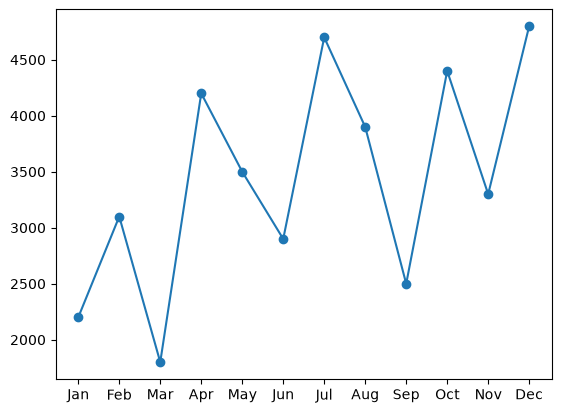

In [13]:
plt.plot(df["Month"],df["Total_Orders"],marker="o")


In [2]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [3]:
#                                                                [   SECTION - C   ]


Menu:
1. Summary Statistics
2. Distribution Analysis
3. Correlation Heatmap
4. Restaurant Performance Report
5. Exit


Enter your choice (1-5):  1



📊 Summary Statistics:
DeliveryTime: mean=53.67, std=20.17, min=20, max=89
Amount: mean=833.05, std=373.86, min=200, max=1480
Rating: mean=3.02, std=1.41, min=1, max=5

Menu:
1. Summary Statistics
2. Distribution Analysis
3. Correlation Heatmap
4. Restaurant Performance Report
5. Exit


Enter your choice (1-5):  2


✅ Distribution chart saved as distribution_analysis.png

Menu:
1. Summary Statistics
2. Distribution Analysis
3. Correlation Heatmap
4. Restaurant Performance Report
5. Exit


...

✅ Correlation heatmap saved as correlation_heatmap.png

Menu:
1. Summary Statistics
2. Distribution Analysis
3. Correlation Heatmap
4. Restaurant Performance Report
5. Exit


Enter your choice (1-5):  4


✅ Restaurant performance chart saved as restaurant_performance.png

Menu:
1. Summary Statistics
2. Distribution Analysis
3. Correlation Heatmap
4. Restaurant Performance Report
5. Exit


Enter your choice (1-5):  5



📑 Final Summary Report:

Top 3 Restaurants by Mean Rating:
Restaurant
KFC            3.406250
Pizza Hub      3.060606
Burger King    3.000000
Name: Rating, dtype: float64

Highest Correlation Pair: OrderID and Amount (corr=-0.17)

Delivery Time → mean=53.67, std=20.17

✅ Program finished. Goodbye!


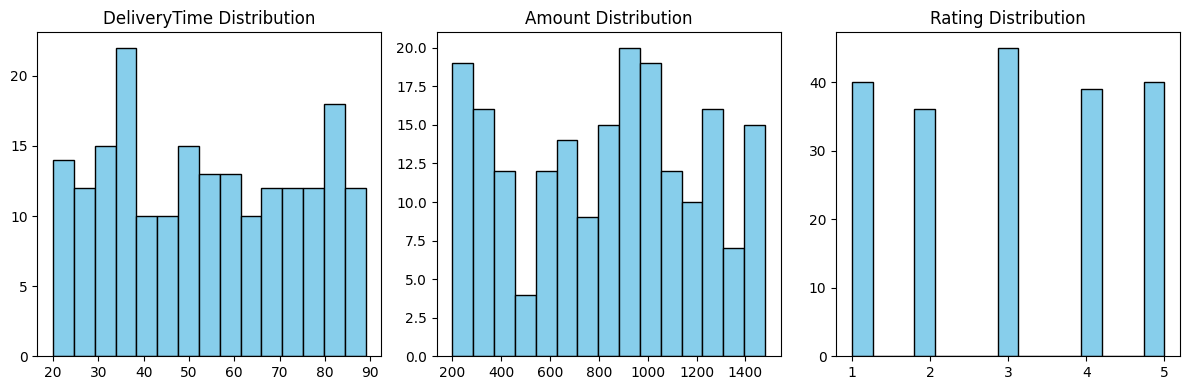

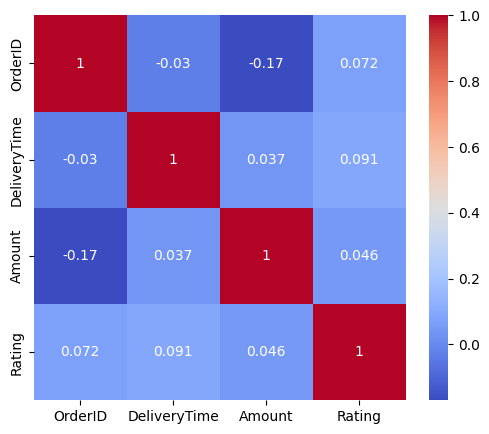

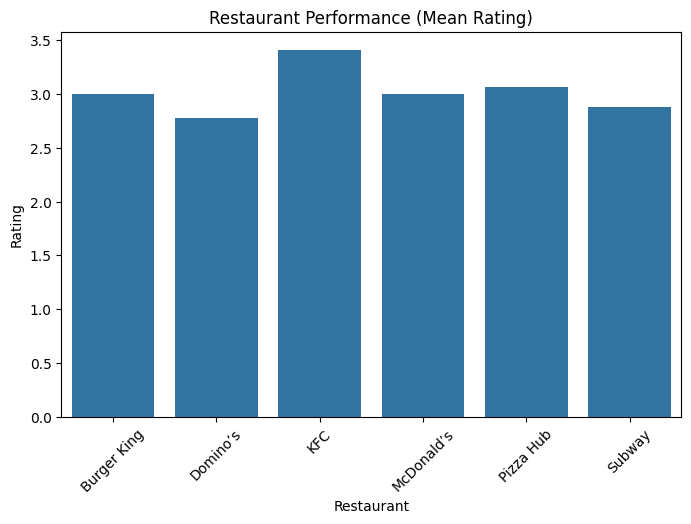

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Step 1: Generate Synthetic Dataset
# -------------------------------
np.random.seed(42)  # reproducibility

restaurants = ["Pizza Hub", "Burger King", "Domino’s", "Subway", "KFC", "McDonald’s"]
cities = ["Ahmedabad", "Surat", "Mumbai", "Delhi", "Pune"]

data = {
    "OrderID": np.arange(1, 201),
    "Restaurant": np.random.choice(restaurants, 200),
    "City": np.random.choice(cities, 200),
    "DeliveryTime": np.random.randint(20, 90, 200),   # minutes
    "Amount": np.random.randint(200, 1500, 200),      # rupees
    "Rating": np.random.randint(1, 6, 200)            # 1–5 stars
}

df = pd.DataFrame(data)

# Fill nulls in numeric columns if any
df.fillna(df.mean(numeric_only=True), inplace=True)

# -------------------------------
# Step 3: Function Implementations
# -------------------------------

# Function 1: Summary Statistics (NumPy)
def summary_statistics(df):
    print("\n📊 Summary Statistics:")
    for col in ["DeliveryTime", "Amount", "Rating"]:
        print(f"{col}: mean={np.mean(df[col]):.2f}, std={np.std(df[col]):.2f}, min={np.min(df[col])}, max={np.max(df[col])}")

# Function 2: Distribution Analysis (Matplotlib)
def distribution_analysis(df):
    fig, axes = plt.subplots(1, 3, figsize=(12,4))
    for ax, col in zip(axes, ["DeliveryTime","Amount","Rating"]):
        ax.hist(df[col], bins=15, color="skyblue", edgecolor="black")
        ax.set_title(f"{col} Distribution")
    plt.tight_layout()
    plt.savefig("distribution_analysis.png", dpi=150)
    print("✅ Distribution chart saved as distribution_analysis.png")

# Function 3: Correlation Heatmap (Seaborn)
def correlation_heatmap(df):
    corr = df.select_dtypes(include=[np.number]).corr(method="pearson")
    plt.figure(figsize=(6,5))
    sns.heatmap(corr, annot=True, cmap="coolwarm")
    plt.savefig("correlation_heatmap.png", dpi=150)
    print("✅ Correlation heatmap saved as correlation_heatmap.png")

# Function 4: Restaurant Performance Report (Pandas groupby)
def restaurant_performance(df):
    perf = df.groupby("Restaurant")[["Rating","Amount","DeliveryTime"]].mean()
    plt.figure(figsize=(8,5))
    sns.barplot(x=perf.index, y=perf["Rating"])
    plt.xticks(rotation=45)
    plt.title("Restaurant Performance (Mean Rating)")
    plt.savefig("restaurant_performance.png", dpi=150)
    print("✅ Restaurant performance chart saved as restaurant_performance.png")

# -------------------------------
# Step 2 + Step 4: Menu Loop with Exit Summary
# -------------------------------
while True:
    print("\nMenu:")
    print("1. Summary Statistics")
    print("2. Distribution Analysis")
    print("3. Correlation Heatmap")
    print("4. Restaurant Performance Report")
    print("5. Exit")

    choice = input("Enter your choice (1-5): ")

    if choice == "1":
        summary_statistics(df)
    elif choice == "2":
        distribution_analysis(df)
    elif choice == "3":
        correlation_heatmap(df)
    elif choice == "4":
        restaurant_performance(df)
    elif choice == "5":
        print("\n📑 Final Summary Report:")

        # 1. Top 3 restaurants by mean rating
        top3 = df.groupby("Restaurant")["Rating"].mean().nlargest(3)
        print("\nTop 3 Restaurants by Mean Rating:")
        print(top3)

        # 2. Highest absolute correlation pair (numeric only)
        corr = df.select_dtypes(include=[np.number]).corr(method="pearson")
        abs_corr = corr.abs().to_numpy().copy()   # make writable copy
        np.fill_diagonal(abs_corr, 0)  # ignore self-correlation
        max_pair = np.unravel_index(np.argmax(abs_corr), abs_corr.shape)
        col1, col2 = corr.columns[max_pair[0]], corr.columns[max_pair[1]]
        print(f"\nHighest Correlation Pair: {col1} and {col2} (corr={corr.loc[col1, col2]:.2f})")

        # 3. Delivery time mean and std
        mean_time = np.mean(df["DeliveryTime"])
        std_time = np.std(df["DeliveryTime"])
        print(f"\nDelivery Time → mean={mean_time:.2f}, std={std_time:.2f}")

        print("\n✅ Program finished. Goodbye!")
        break
    else:
        print("Invalid choice. Please try again.")

In [8]:
#                                                                [   SECTION - d   ]

In [ ]:
Generate a synthetic food delivery dataset using NumPy with at least 5 numeric columns and one categorical column, 
and load it into a Pandas DataFrame. Create a Seaborn pairplot of all numeric columns, colored by the categorical column, and save it as a PNG file. 
Calculate the Pearson correlation matrix and display it as a Seaborn heatmap with annotated values and a diverging color palette.
Save the heatmap as a separate PNG file at 200 DPI with a descriptive filename.

In [17]:
#                                                                     Task - 1
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Random data generate karna
np.random.seed(42)

data = {
    "order_value": np.random.randint(100, 1000, 100),  #np.random.randint() random integer values banata hai.
    "delivery_time": np.random.randint(15, 60, 100),
    "rating": np.random.uniform(1, 5, 100).round(1), # np.random.uniform() decimal values banata hai.
    "distance_km": np.random.uniform(1, 15, 100).round(1),
    "preparation_time": np.random.randint(5, 30, 100),
    "cuisine_type": np.random.choice(  #np.random.choice() categories mein se random category select karta hai.
        ["Indian", "Chinese", "Italian"], 100)}
food_df = pd.DataFrame(data)   # DataFrame banana
food_df.head()    # Dataset dekhna

,order_value,delivery_time,rating,distance_km,preparation_time,cuisine_type
0,202,22,4.6,8.1,17,Italian
1,535,28,2.1,9.9,25,Chinese
2,960,37,3.6,4.5,5,Indian
3,370,54,1.0,9.3,20,Italian
4,206,35,2.4,14.7,11,Italian


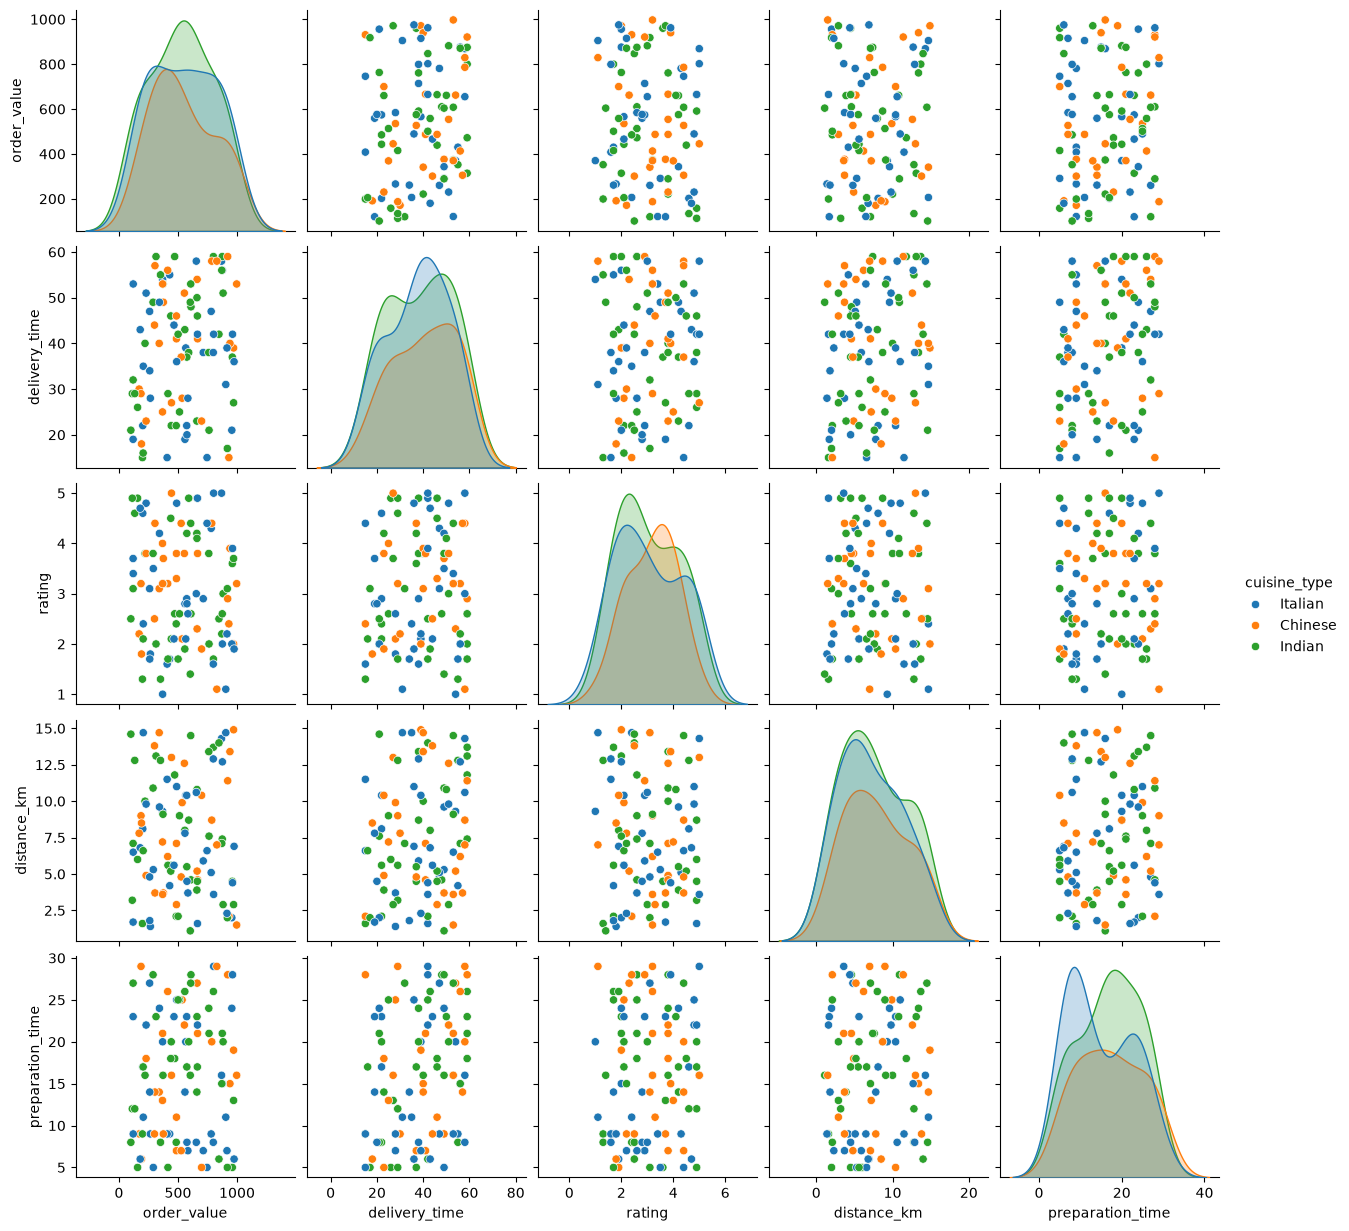

In [19]:
sns.pairplot(food_df,vars=["order_value","delivery_time","rating","distance_km","preparation_time"],hue="cuisine_type")

plt.savefig("food_delivery_pairplot.png",dpi=200,bbox_inches="tight")  # file save kane ke liye

plt.show()

In [21]:
correlation_matrix = food_df[["order_value","delivery_time","rating","distance_km","preparation_time"]].corr(method="pearson")
#.corr(method="pearson") Pearson correlation calculate karta hai.
#correlation_matrix mein har numerical column ka doosre numerical columns ke saath correlation store hota hai.
correlation_matrix

,order_value,delivery_time,rating,distance_km,preparation_time
order_value,1.000000,0.174388,-0.099104,-0.019233,0.101080
delivery_time,0.174388,1.000000,0.062461,0.189442,0.272060
rating,-0.099104,0.062461,1.000000,-0.041080,0.071669
distance_km,-0.019233,0.189442,-0.041080,1.000000,0.060310
preparation_time,0.101080,0.272060,0.071669,0.060310,1.000000


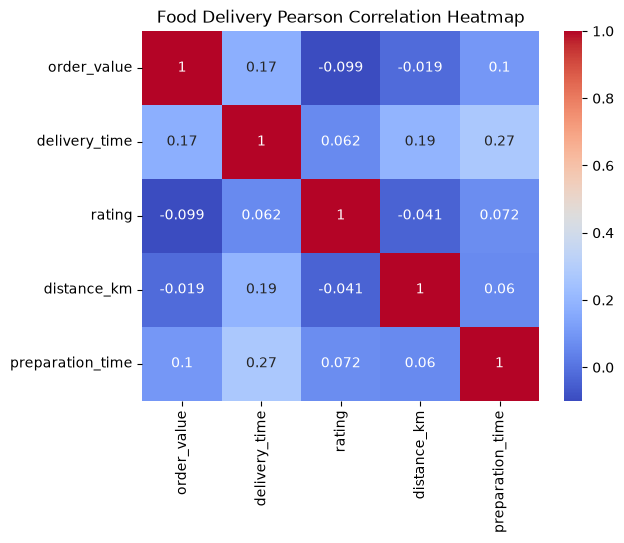

In [31]:
sns.heatmap(correlation_matrix,annot=True,cmap="coolwarm")
plt.title("Food Delivery Pearson Correlation Heatmap")
plt.savefig("food_delivery_correlation_heatmap.png",dpi=200)



In [ ]:
I improved the AI-generated code by using pair_grid.savefig() to save the pairplot directly from its figure object. 
I also added dropna() to handle missing values in the categorical column before plotting. 
This makes the pairplot export more reliable and avoids issues caused by missing category labels. 
The heatmap is saved separately at 200 DPI.